In [1]:
# Importing the necessary libraries
import os
import pyodbc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Server and database come from environment variables, so no machine name is hard-coded.
# Set SQL_SERVER (e.g. localhost\SQLEXPRESS) and SQL_DATABASE before running, or keep the defaults.
SQL_SERVER = os.getenv("SQL_SERVER", r"localhost\SQLEXPRESS")
SQL_DATABASE = os.getenv("SQL_DATABASE", "OnlineRetailII")

# Connecting with SQL Server
connection = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    f"Server={SQL_SERVER};"
    f"Database={SQL_DATABASE};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

In [2]:
# Loading the data
query = "EXEC rpt.calculateRFMtable"
df = pd.read_sql(query, connection)
print(df.head(5))
print(df.describe())

C:\Users\psoma\AppData\Local\Temp\ipykernel_13332\2232438241.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


   customer_id  Recency  Frequency   Monetary
0        18102        0        145  580987.04
1        14646        1        145  526751.52
2        14156        9        144  303069.88
3        14911        1        373  272252.79
4        17450        8         51  244784.25
        customer_id      Recency    Frequency       Monetary
count   5852.000000  5852.000000  5852.000000    5852.000000
mean   15319.707109   199.732399     6.253247    2916.609242
std     1714.929942   208.523287    12.749286   14306.292958
min    12346.000000     0.000000     1.000000       2.950000
25%    13837.750000    25.000000     1.000000     339.575000
50%    15320.500000    95.000000     3.000000     856.020000
75%    16802.250000   379.000000     7.000000    2241.030000
max    18287.000000   738.000000   373.000000  580987.040000


C:\Users\psoma\AppData\Local\Temp\ipykernel_13332\934219988.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders_df = pd.read_sql(query, connection)


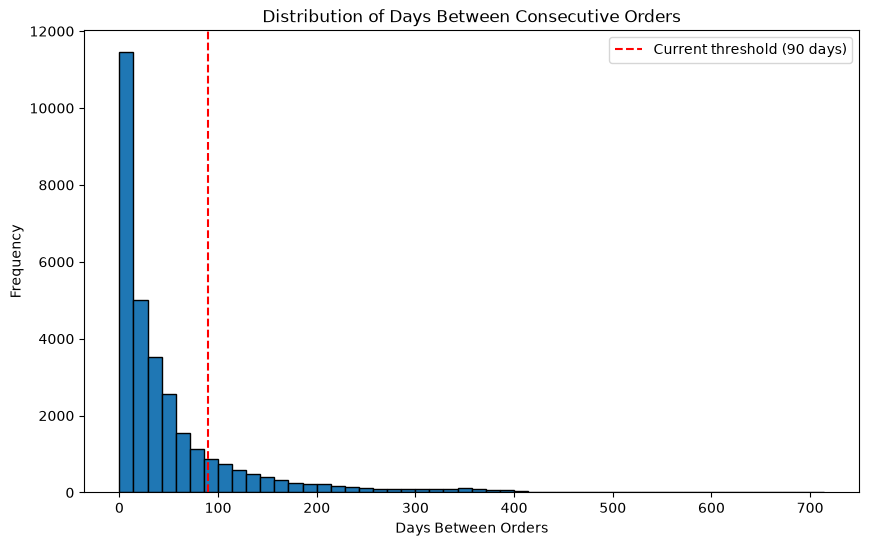

count    30742.000000
mean        52.121658
std         75.904468
min          0.000000
25%          7.000000
50%         25.000000
75%         62.000000
max        714.000000
Name: days_since_last_order, dtype: float64


In [3]:
query = """
    SELECT customer_id, order_date
    FROM rpt.vw_orders
    ORDER BY customer_id, order_date
"""
orders_df = pd.read_sql(query, connection)

# Calculate days between consecutive orders, per customer
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
orders_df['days_since_last_order'] = orders_df.groupby('customer_id')['order_date'].diff().dt.days

# Drop NaN (each customer's first order has no "previous" order to compare)
gaps = orders_df['days_since_last_order'].dropna()

# Visualize the distribution
plt.figure(figsize=(10, 6))
plt.hist(gaps, bins=50, edgecolor='black')
plt.axvline(90, color='red', linestyle='--', label='Current threshold (90 days)')
plt.xlabel('Days Between Orders')
plt.ylabel('Frequency')
plt.title('Distribution of Days Between Consecutive Orders')
plt.legend()
plt.show()

print(gaps.describe())

In [4]:
# Converting each customer into churned or not
df['Churned'] = (df['Recency'] > 90).astype(int)
print(df['Churned'].value_counts())

Churned
1    2967
0    2885
Name: count, dtype: int64



Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.52      0.62       577
           1       0.65      0.85      0.73       594

    accuracy                           0.69      1171
   macro avg       0.71      0.68      0.68      1171
weighted avg       0.71      0.69      0.68      1171


Coefficients:
     Feature  Coefficient
0  Frequency    -2.467015
1   Monetary    -0.200337


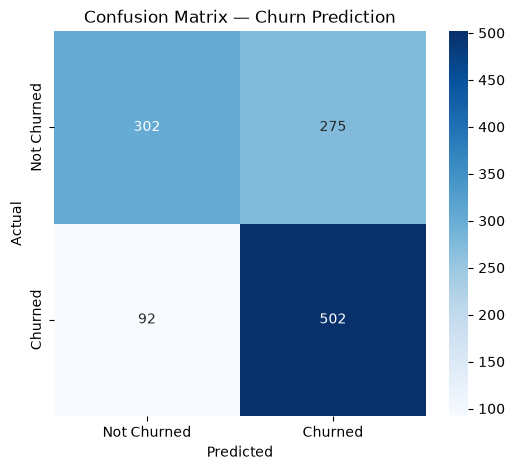

In [5]:
# Defining the dependent and outcome variables
X = df[['Frequency', 'Monetary']]
Y = df['Churned']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Scale Frequency and Monetary so the coefficients are comparable
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # learn mean/std from train only
X_test_s = scaler.transform(X_test)        # reuse the same mean/std on test

# Creating a logistic regression model, fitting the scaled data into it, and predicting on test set
model = LogisticRegression(random_state=42)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

# Evaluate
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Coefficients — which features drive churn prediction
print("\nCoefficients:")
print(pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]}))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Not Churned', 'Churned'],yticklabels=['Not Churned', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Churn Prediction')
plt.show()

C:\Users\psoma\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


ROC-AUC Score: 0.749


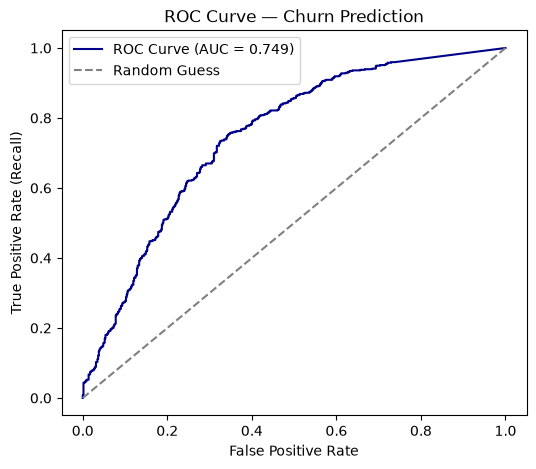

In [6]:
# predict_proba returns two columns per customer:
all_probabilities = model.predict_proba(X_test)

# column 0 = probability of NOT churning, column 1 = probability of churning
prob_not_churned = all_probabilities[:, 0]
prob_churned = all_probabilities[:, 1]

# Compare the churn probabilities against the real answers
# (1 = churned, 0 = stayed). Higher AUC = better ranking of churners above stayers.
auc_score = roc_auc_score(y_true=y_test, y_score=prob_churned)
print("ROC-AUC Score:", round(auc_score, 3))

# Try many cutoffs and record the results at each one
false_positive_rate, true_positive_rate, cutoffs = roc_curve(y_true=y_test, y_score=prob_churned)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(false_positive_rate, true_positive_rate, label=f'ROC Curve (AUC = {auc_score:.3f})', color='darkblue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Churn Prediction')
plt.legend()
plt.show()

In [7]:
df['churn_probability'] = model.predict_proba(scaler.transform(X))[:, 1]
df[['Frequency', 'Monetary', 'Churned', 'churn_probability']].head()
print(df.groupby('Churned')['churn_probability'].mean())

Churned
0    0.419708
1    0.596089
Name: churn_probability, dtype: float64


In [9]:
from sqlalchemy import create_engine, text

engine = create_engine(
    f"mssql+pyodbc://{SQL_SERVER}/{SQL_DATABASE}"
    "?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

churn_out = df[['customer_id', 'Churned', 'churn_probability']]
print(churn_out.groupby('Churned')['churn_probability'].mean())   # expect about 0.42 / 0.60

with engine.connect() as conn:
    seg = pd.read_sql(
        text("SELECT customer_id, Recency, Frequency, Monetary, Cluster, Segment FROM rpt.customer_segments"),
        conn
    )

final = seg.merge(churn_out, on='customer_id', how='left')
print(final.shape, final['Churned'].isna().sum())   # expect (5852, 8) and 0

final.to_sql('customer_segments_staging', engine, schema='rpt', if_exists='replace', index=False)

Churned
0    0.419708
1    0.596089
Name: churn_probability, dtype: float64
(5852, 8) 0


88